# Data Integration

Data sources: Brazilian E-Commerce Public Dataset by Olist; MNIST image number dataset


In [9]:
!pip install kagglehub pandas

In [10]:
import pandas as pd
import numpy as np
import os
import kagglehub

# Descarga/Acceso al path
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

# Lista de archivos a cargar
files = [
    'olist_customers_dataset.csv', 'olist_order_items_dataset.csv',
    'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv',
    'olist_orders_dataset.csv', 'olist_products_dataset.csv',
    'olist_sellers_dataset.csv', 'product_category_name_translation.csv'
]

# Carga automática
dfs = {}
for f in files:
    name = f.replace('.csv', '').replace('olist_', '').replace('_dataset', '')
    dfs[name] = pd.read_csv(os.path.join(path, f))
    print(f"Cargado: {name} ({dfs[name].shape[0]} filas)")

Cargado: customers (99441 filas)
Cargado: order_items (112650 filas)
Cargado: order_payments (103886 filas)
Cargado: order_reviews (99224 filas)
Cargado: orders (99441 filas)
Cargado: products (32951 filas)
Cargado: sellers (3095 filas)
Cargado: product_category_name_translation (71 filas)


In [11]:
# 1. Órdenes + Clientes
m = pd.merge(dfs['orders'], dfs['customers'], on='customer_id', how='left')

# 2. + Ítems (Aquí la tabla crece porque una orden puede tener varios productos)
m = pd.merge(m, dfs['order_items'], on='order_id', how='left')

# 3. + Productos y su traducción
m = pd.merge(m, dfs['products'], on='product_id', how='left')
m = pd.merge(m, dfs['product_category_name_translation'], on='product_category_name', how='left')

# 4. + Vendedores
m = pd.merge(m, dfs['sellers'], on='seller_id', how='left')

# 5. + Pagos y Reseñas
# Nota: Una orden puede tener varios pagos o varias reseñas. 
# Para evitar duplicados excesivos, podrías querer agruparlos, pero por ahora los unimos:
m = pd.merge(m, dfs['order_payments'], on='order_id', how='left')
m = pd.merge(m, dfs['order_reviews'], on='order_id', how='left')

print(f"\nDataset integrado final. Total de filas: {m.shape[0]}")


Dataset integrado final. Total de filas: 119143


In [12]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import Dataset
import os
import glob
import random
import pandas as pd

# Definimos la ruta central de datos una sola vez
DATA_DIR = '../data'

# --- Tu lógica de limpieza de MNIST ---
# 1. Descarga apuntando al nuevo directorio
mnist_train = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=transforms.ToTensor())

# 2. Limpieza apuntando al nuevo directorio
raw_folder = os.path.join(DATA_DIR, 'MNIST/raw')
gz_files = glob.glob(os.path.join(raw_folder, '*.gz'))

if gz_files:
    for file in gz_files:
        os.remove(file)
    print("Cleanup complete! Only uncompressed files remain.")

# --- Tu clase DoubleDigitMNIST ---
class DoubleDigitMNIST(Dataset):
    # 3. Cambiamos el valor por defecto de root_dir
    def __init__(self, root_dir=DATA_DIR, train=True):
        self.original_mnist = datasets.MNIST(
            root=root_dir, train=train, download=False, transform=transforms.ToTensor()
        )
        
    def __len__(self):
        return len(self.original_mnist)
        
    def __getitem__(self, idx):
        img1, label1 = self.original_mnist[idx]
        idx2 = random.randint(0, len(self.original_mnist) - 1)
        img2, label2 = self.original_mnist[idx2]
        
        # Concatenación horizontal: Imagen resultante de 1x28x56
        combined_img = torch.cat((img1, img2), dim=2)
        combined_label = label1 * 10 + label2
        return combined_img, combined_label

# Instanciamos el generador de imágenes de estados
state_images_gen = DoubleDigitMNIST(train=True)
print(f"Generador instanciado correctamente usando datos de: {DATA_DIR}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 9.32MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 217kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.4MB/s]

Cleanup complete! Only uncompressed files remain.
Generador instanciado correctamente usando datos de: ../data


In [13]:
# 1. Crear el mapeo único (27 estados)
unique_states = sorted(m['customer_state'].unique())
state_to_num = {state: i for i, state in enumerate(unique_states)}
num_to_state = {v: k for k, v in state_to_num.items()}

# 2. Codificar las columnas
m['customer_state_num'] = m['customer_state'].map(state_to_num)
m['seller_state_num'] = m['seller_state'].map(state_to_num)

# 3. UNIFICACIÓN A ENTERO (Manejo de NaNs)
# Llenamos los nulos con -1 y convertimos a int
m['customer_state_num'] = m['customer_state_num'].fillna(-1).astype(int)
m['seller_state_num'] = m['seller_state_num'].fillna(-1).astype(int)

# 4. Eliminar las originales
m.drop(columns=['customer_state', 'seller_state'], inplace=True)

# 5. Imprimir tabla de referencia
print("Unificación completada. Tipos de datos:")
print(m[['customer_state_num', 'seller_state_num']].dtypes)

print(f"\n{'Nº':<5} | {'Estado Original':<10}")
print("-" * 22)
for num, state in num_to_state.items():
    print(f"{num:>2}    | {state}")
print(f" -1    | Desconocido (NaN)")
print("-" * 22)

Unificación completada. Tipos de datos:
customer_state_num    int64
seller_state_num      int64
dtype: object

Nº    | Estado Original
----------------------
 0    | AC
 1    | AL
 2    | AM
 3    | AP
 4    | BA
 5    | CE
 6    | DF
 7    | ES
 8    | GO
 9    | MA
10    | MG
11    | MS
12    | MT
13    | PA
14    | PB
15    | PE
16    | PI
17    | PR
18    | RJ
19    | RN
20    | RO
21    | RR
22    | RS
23    | SC
24    | SE
25    | SP
26    | TO
 -1    | Desconocido (NaN)
----------------------


In [14]:
# 1. Banco de Imágenes Estricto (0-26)
state_visual_dict = {}

print("Generando representaciones visuales solo para estados válidos (0-26)...")

# Solo iteramos hasta cubrir los 27 estados reales de Brasil
while len(state_visual_dict) < len(unique_states):
    img, label = state_images_gen[random.randint(0, len(state_images_gen)-1)]
    
    # Filtro: Solo si el label está entre 0 y 26 y no lo tenemos ya
    if label in state_to_num.values() and label not in state_visual_dict:
        state_visual_dict[label] = img

# 2. Verificación crucial:
if -1 in state_visual_dict:
    print("⚠️ Error detectado: -1 estaba en el dict. Eliminando...")
    del state_visual_dict[-1]

print(f"¡Hecho! Diccionario limpio con {len(state_visual_dict)} estados.")

Generando representaciones visuales solo para estados válidos (0-26)...
¡Hecho! Diccionario limpio con 27 estados.


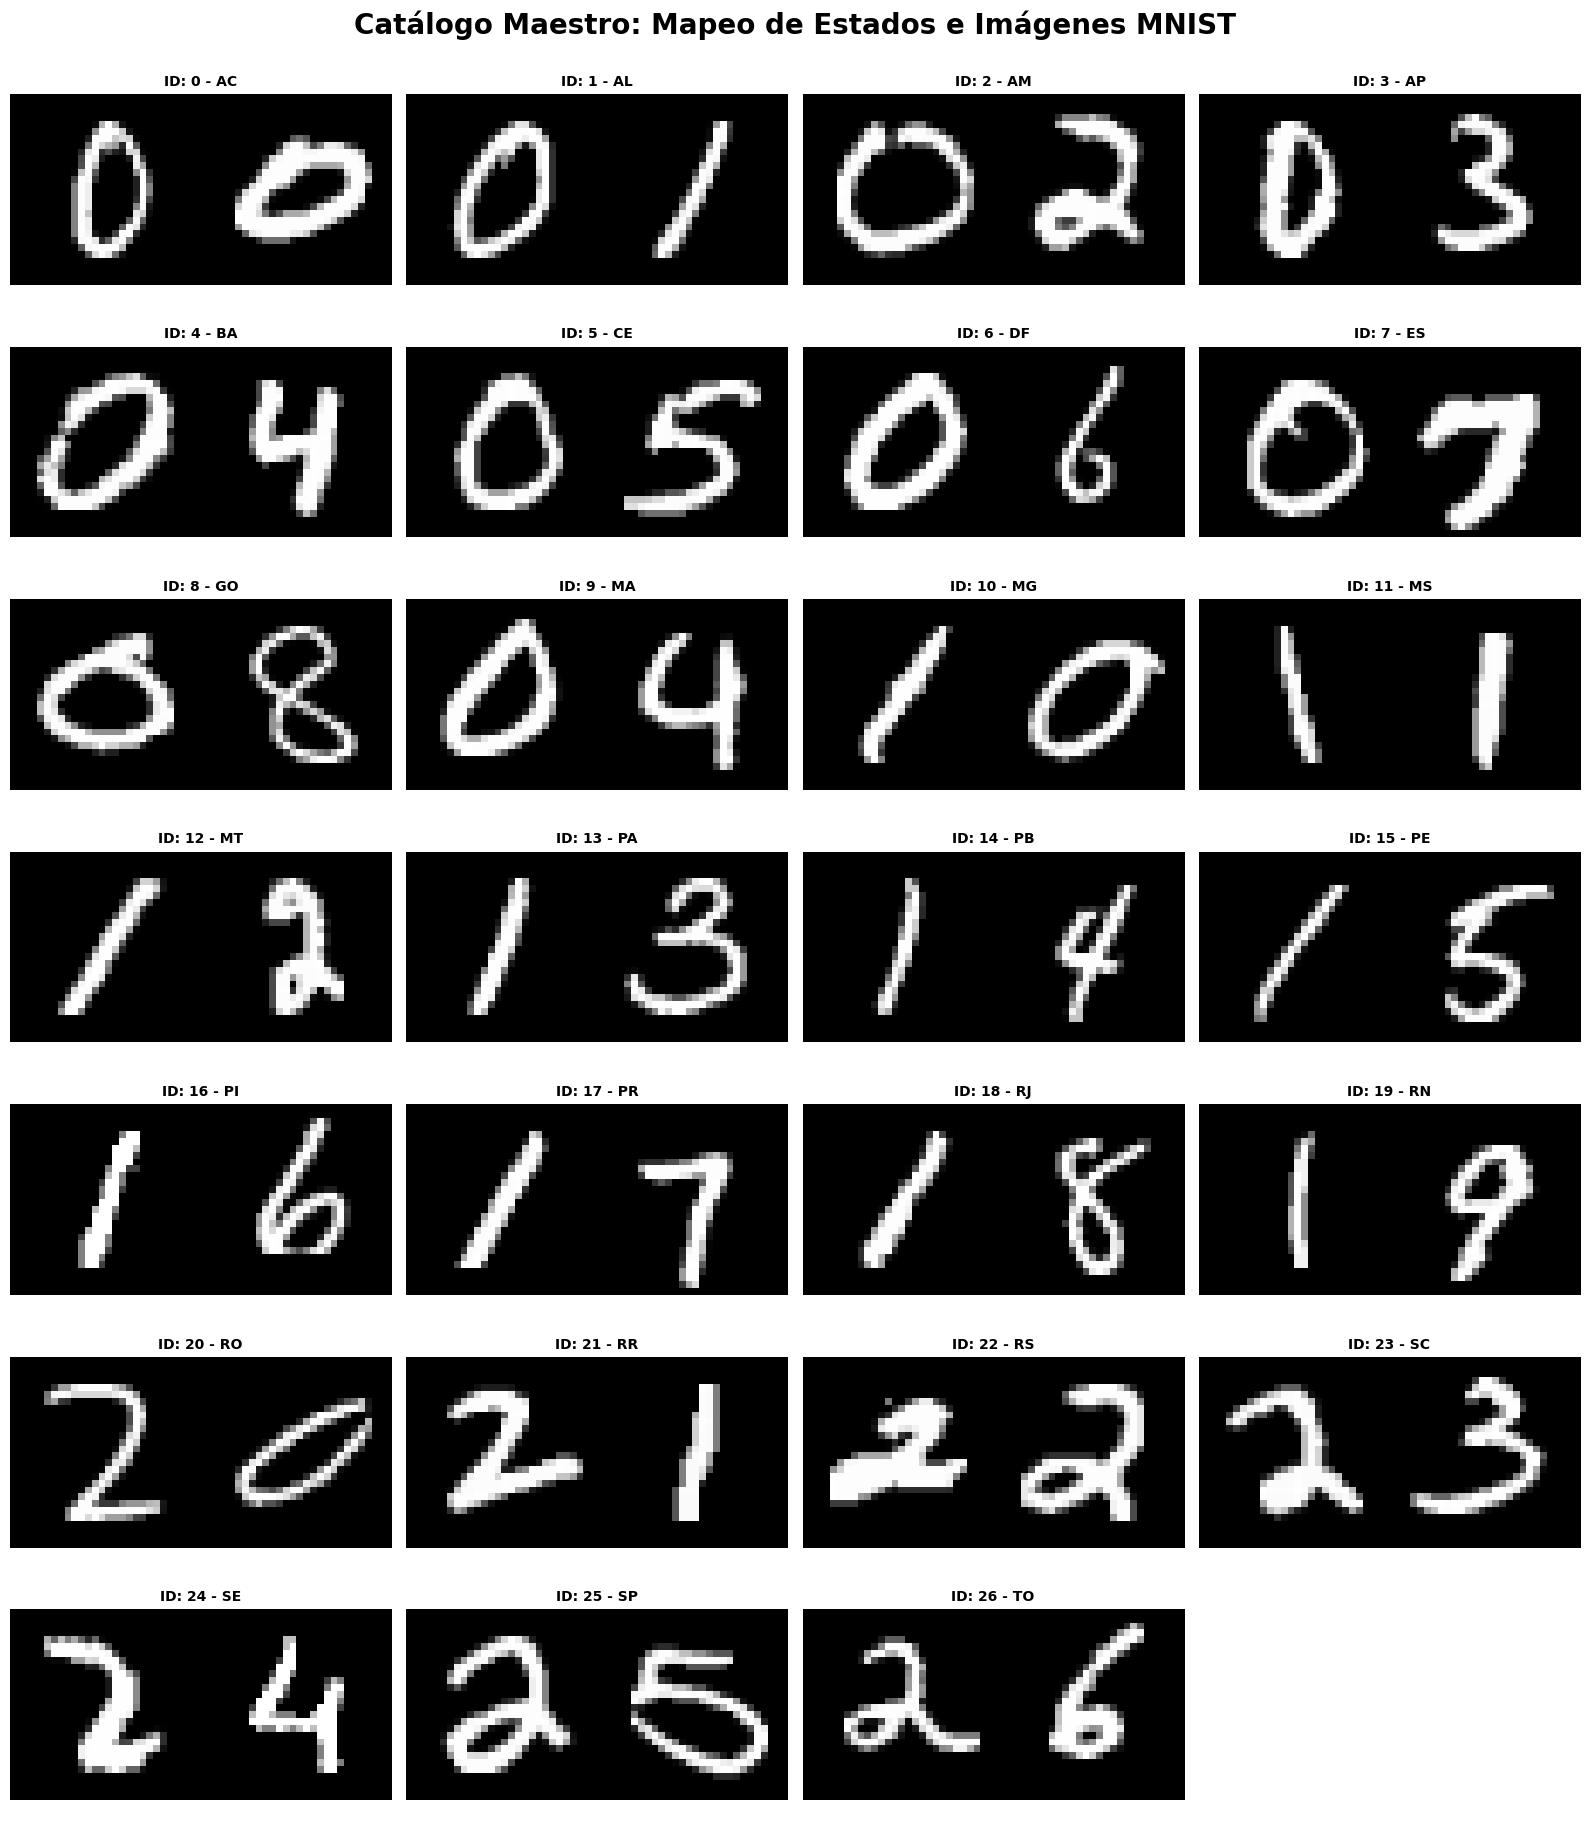

In [15]:
import matplotlib.pyplot as plt

# 1. Lista de todos los IDs a mostrar (incluyendo el -1)
# Usamos los IDs presentes en nuestro diccionario de nombres
ids_a_mostrar = sorted(num_to_state.keys()) 

# 2. Configurar la rejilla (28 elementos: 7 filas x 4 columnas es ideal)
fig, axes = plt.subplots(nrows=7, ncols=4, figsize=(16, 18))
axes = axes.flatten()

for i, state_id in enumerate(ids_a_mostrar):
    ax = axes[i]
    state_name = num_to_state[state_id]
    
    # Lógica de imagen: si es -1 o no está en el dict, no mostramos imagen
    if state_id != -1 and state_id in state_visual_dict:
        img = state_visual_dict[state_id].squeeze()
        ax.imshow(img, cmap='gray')
    else:
        # Aquí es donde "no tiene imagen"
        # Dibujamos un cuadro gris claro o simplemente dejamos el texto
        ax.add_patch(plt.Rectangle((0,0), 56, 28, color='whitesmoke'))
        ax.text(28, 14, 'SIN IMAGEN', ha='center', va='center', 
                fontsize=8, color='gray', fontweight='bold')
        # Ajustamos los límites para que el cuadro se vea del mismo tamaño que las imágenes
        ax.set_xlim(0, 56)
        ax.set_ylim(28, 0)

    # Título del recuadro
    ax.set_title(f"ID: {state_id} - {state_name}", fontsize=10, fontweight='bold')
    ax.axis('off')

# 3. Limpiar los ejes sobrantes (si la rejilla es más grande que el número de estados)
for j in range(len(ids_a_mostrar), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle("Catálogo Maestro: Mapeo de Estados e Imágenes MNIST", 
             fontsize=20, y=1.02, fontweight='bold')
plt.show()

In [16]:
import os
import pandas as pd

# Asegurar que la carpeta existe
os.makedirs('../data', exist_ok=True)

# 1. DATASET TABULAR (Sin imágenes)
# Guardamos todo el progreso que llevamos, incluyendo las columnas numéricas
df_tabular = m.copy()
df_tabular.to_csv('../data/m_tabular.csv', index=False)
print("✅ Dataset tabular guardado (CSV).")

# 2. DATASET IMÁGENES CLIENTE (id + imagen)
# Usamos un subset para no saturar la RAM si m es muy grande
# Si quieres hacerlo con todo el dataset, asegúrate de tener RAM suficiente
m_sub = m.copy() # Cambiar a m.copy() para el dataset real

df_cust_img = m_sub[['order_id', 'customer_state_num']].copy()
df_cust_img['customer_state_image'] = df_cust_img['customer_state_num'].map(state_visual_dict)
df_cust_img.drop(columns=['customer_state_num'], inplace=True)
df_cust_img.to_pickle('../data/m_cust_images.pkl')
print("✅ Dataset de imágenes de clientes guardado (Pickle).")

# 3. DATASET IMÁGENES VENDEDOR (id + imagen)
df_sell_img = m_sub[['order_id', 'seller_state_num']].copy()
df_sell_img['seller_state_image'] = df_sell_img['seller_state_num'].map(state_visual_dict)
df_sell_img.drop(columns=['seller_state_num'], inplace=True)
df_sell_img.to_pickle('../data/m_sell_images.pkl')
print("✅ Dataset de imágenes de vendedores guardado (Pickle).")

✅ Dataset tabular guardado (CSV).
✅ Dataset de imágenes de clientes guardado (Pickle).
✅ Dataset de imágenes de vendedores guardado (Pickle).
